<a href="https://colab.research.google.com/github/germfsip/Agentes-Inteligentes-2026/blob/main/Unir_AI_Sesion3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 3 — Convolutional Neural Networks (CNN)

**Asignatura:** Sistemas Cognitivos Artificiales — Maestría UNIR México  
**Profesor:** Gerardo A. Martínez Fernández  
**Tema 5:** Convolutional Neural Networks (CNN)

---

## Objetivos de esta práctica

1. Construir una CNN desde cero con Keras para clasificar CIFAR-10
2. Visualizar feature maps y entender qué aprende cada capa
3. Aplicar Data Augmentation y medir su impacto
4. Implementar Transfer Learning con VGG16 preentrenada

> ⚡ **Importante:** Activa la GPU en *Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU*

## Parte 1: Setup y exploración de CIFAR-10

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cargar CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar a [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Nombres de las clases
CLASES = ['Avión', 'Auto', 'Pájaro', 'Gato', 'Ciervo',
           'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Clases: {len(CLASES)}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 453s 3us/step
Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)
Clases: 10


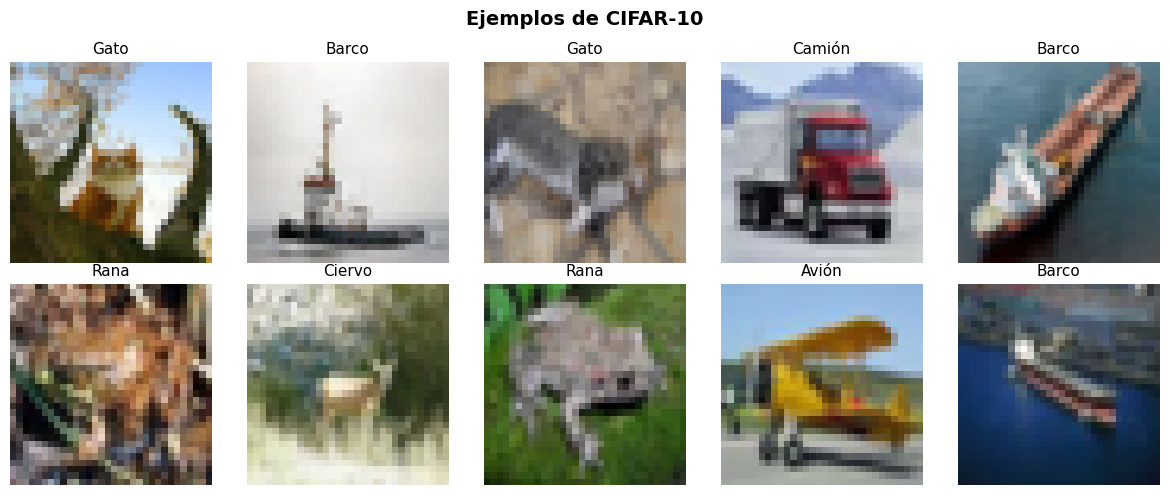

In [3]:
# Visualizar ejemplos del dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(x_train))
    ax.imshow(x_train[idx])
    ax.set_title(CLASES[y_train[idx][0]], fontsize=11)
    ax.axis('off')
plt.suptitle('Ejemplos de CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Parte 2: CNN desde cero

Arquitectura: 3 bloques CONV→ReLU→MaxPool + 2 FC + Softmax

In [4]:
def crear_cnn_basica():
    """CNN con 3 bloques convolucionales."""
    model = models.Sequential([
        # Bloque 1: 32 filtros 3x3
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                       input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),

        # Bloque 2: 64 filtros 3x3
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Bloque 3: 128 filtros 3x3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Clasificador
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

modelo_basico = crear_cnn_basica()
modelo_basico.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Compilar y entrenar
modelo_basico.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historia_basico = modelo_basico.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.3946 - loss: 1.6586 - val_accuracy: 0.4436 - val_loss: 1.5298
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5513 - loss: 1.2520 - val_accuracy: 0.6326 - val_loss: 1.0646
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6198 - loss: 1.0816 - val_accuracy: 0.6712 - val_loss: 0.9291
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6613 - loss: 0.9738 - val_accuracy: 0.6962 - val_loss: 0.8786
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6914 - loss: 0.8877 - val_accuracy: 0.7144 - val_loss: 0.8040
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7173 - loss: 0.8120 - val_accuracy: 0.7144 - val_loss: 0.8077
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7338 - loss: 0.7623 - val_accuracy: 0.7232 - val_loss: 0.7980
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7511 - loss: 0.7133 - val_accuracy: 

In [6]:
# Evaluar en test
test_loss, test_acc = modelo_basico.evaluate(x_test, y_test, verbose=0)
print(f"\n📊 Accuracy en test (CNN básica): {test_acc:.4f}")


📊 Accuracy en test (CNN básica): 0.7466


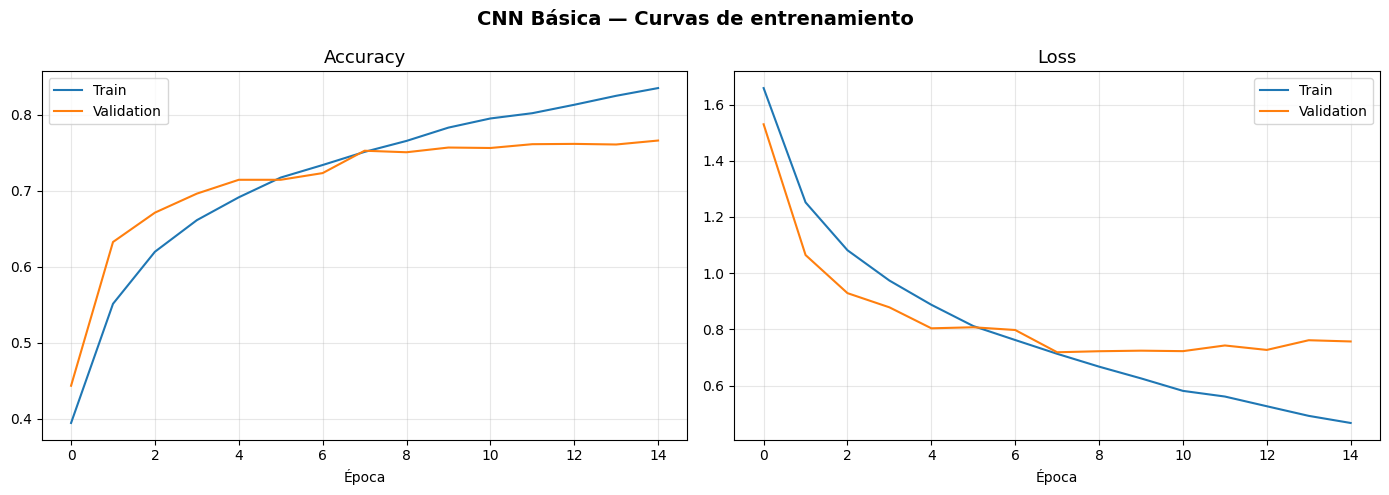

In [7]:
# Gráficas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(historia_basico.history['accuracy'], label='Train')
ax1.plot(historia_basico.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy', fontsize=13)
ax1.set_xlabel('Época')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(historia_basico.history['loss'], label='Train')
ax2.plot(historia_basico.history['val_loss'], label='Validation')
ax2.set_title('Loss', fontsize=13)
ax2.set_xlabel('Época')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN Básica — Curvas de entrenamiento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Parte 3: Visualización de feature maps

Veamos qué "ve" cada capa de la CNN.

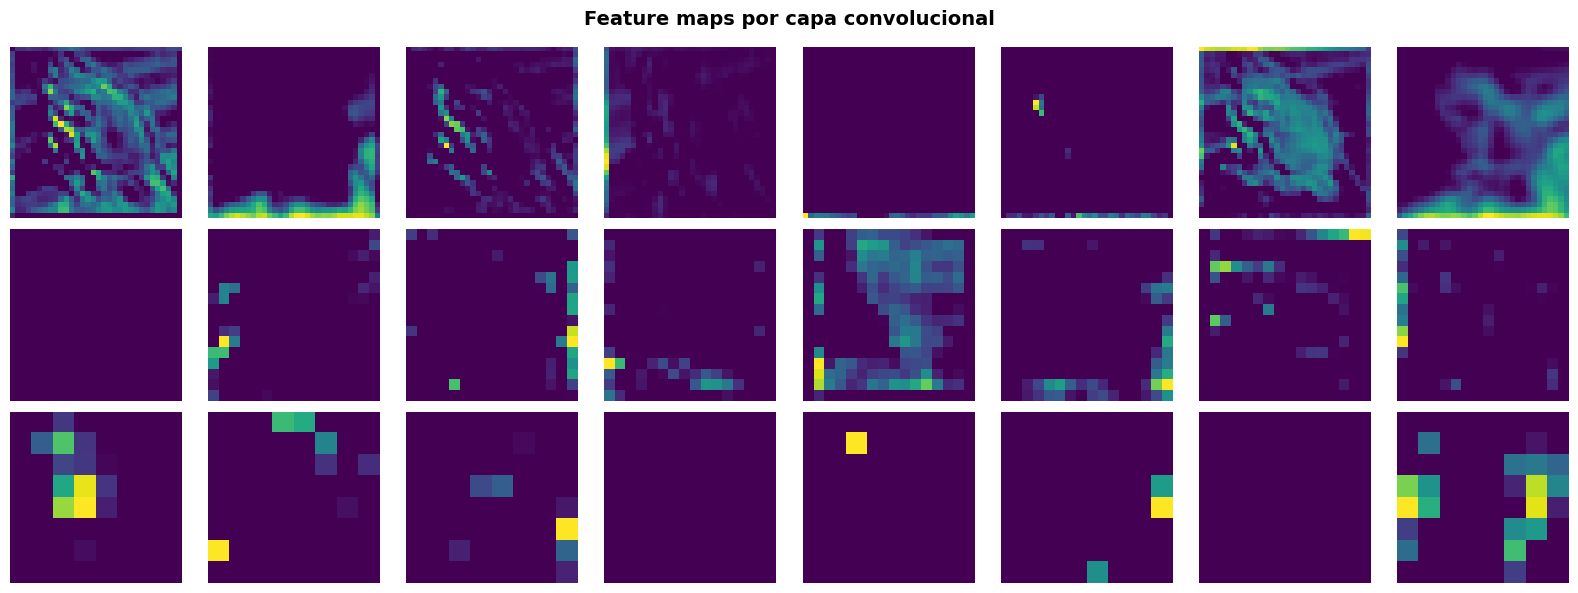

Observa: las primeras capas detectan bordes y texturas.
Las capas más profundas tienen activaciones más abstractas.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Modelo de visualización: input → salidas de cada capa conv
# Fix: Explicitly define an Input layer and trace the model's layers

# Create a symbolic input tensor with the expected shape of modelo_basico
# Use modelo_basico.input_shape to get the shape, excluding the batch dimension (None)
input_for_feature_model = keras.Input(shape=modelo_basico.input_shape[1:])

# List to hold the output tensors of the convolutional layers
layer_outputs_for_feature_model = []

# Iterate through the layers of modelo_basico
# and apply them sequentially to build the feature extraction model
x = input_for_feature_model
for layer in modelo_basico.layers:
    x = layer(x) # Apply the current layer to the tensor 'x'
    if isinstance(layer, layers.Conv2D):
        layer_outputs_for_feature_model.append(x)

# Create the new modelo_vis using the explicitly defined input and collected outputs
modelo_vis = models.Model(inputs=input_for_feature_model, outputs=layer_outputs_for_feature_model)

# Elegir una imagen de ejemplo
img_ejemplo = x_test[7:8]  # Un caballo
activaciones = modelo_vis.predict(img_ejemplo, verbose=0)

# Visualizar feature maps de cada capa
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
titulos = ['Capa 1 (32 filtros)', 'Capa 2 (64 filtros)', 'Capa 3 (128 filtros)']

for capa_idx, act in enumerate(activaciones):
    for filtro_idx in range(8):
        ax = axes[capa_idx, filtro_idx]
        ax.imshow(act[0, :, :, filtro_idx], cmap='viridis')
        ax.axis('off')
        if filtro_idx == 0:
            ax.set_ylabel(titulos[capa_idx], fontsize=10)

plt.suptitle('Feature maps por capa convolucional', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Observa: las primeras capas detectan bordes y texturas.")
print("Las capas más profundas tienen activaciones más abstractas.")

## Parte 4: Data Augmentation

Aplicamos transformaciones en tiempo real para mejorar la generalización.

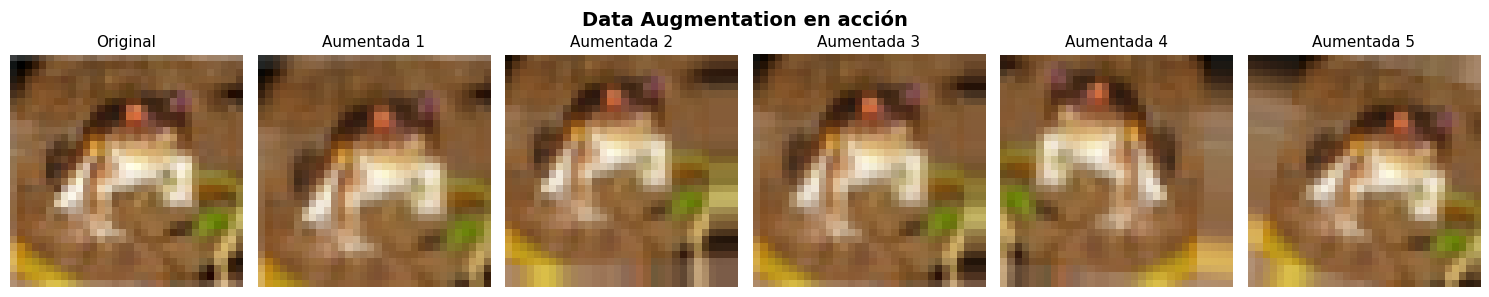

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configurar Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
)

# Visualizar ejemplos aumentados
img_original = x_train[0:1]
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(img_original[0])
axes[0].set_title('Original', fontsize=11)
axes[0].axis('off')

for i, batch in enumerate(datagen.flow(img_original, batch_size=1)):
    if i >= 5:
        break
    axes[i+1].imshow(batch[0])
    axes[i+1].set_title(f'Aumentada {i+1}', fontsize=11)
    axes[i+1].axis('off')

plt.suptitle('Data Augmentation en acción', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Entrenar con Data Augmentation
modelo_aug = crear_cnn_basica()
modelo_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Split manual para validación
val_split = 5000
x_val, y_val = x_train[:val_split], y_train[:val_split]
x_train_aug, y_train_aug = x_train[val_split:], y_train[val_split:]

datagen.fit(x_train_aug)

historia_aug = modelo_aug.fit(
    datagen.flow(x_train_aug, y_train_aug, batch_size=64),
    epochs=15,
    validation_data=(x_val, y_val),
    steps_per_epoch=len(x_train_aug) // 64,
    verbose=1
)

test_loss_aug, test_acc_aug = modelo_aug.evaluate(x_test, y_test, verbose=0)
print(f"\n📊 Accuracy en test (con Data Augmentation): {test_acc_aug:.4f}")
print(f"   vs. CNN básica: {test_acc:.4f}")
print(f"   Diferencia: {(test_acc_aug - test_acc)*100:+.2f}%")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
703/703 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.3440 - loss: 1.7751 - val_accuracy: 0.5110 - val_loss: 1.3557
Epoch 2/15
  1/703 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4219 - loss: 1.5304

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - accuracy: 0.4219 - loss: 1.5304 - val_accuracy: 0.5084 - val_loss: 1.3760
Epoch 3/15
703/703 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.4741 - loss: 1.4546 - val_accuracy: 0.5650 - val_loss: 1.1840
Epoch 4/15
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - accuracy: 0.5781 - loss: 1.2350 - val_accuracy: 0.5712 - val_loss: 1.1656
Epoch 5/15
703/703 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.5333 - loss: 1.3145 - val_accuracy: 0.6188 - val_loss: 1.0644
Epoch 6/15
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - accuracy: 0.5312 - loss: 1.2301 - val_accuracy: 0.6140 - val_loss: 1.0650
Epoch 7/15
703/703 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.5715 - loss: 1.2138 - val_accuracy: 0.6446 - val_loss: 1.0218
Epoch 8/15
703/703 ━━━━━━━━━━━━━━━━━━━━ 1s 752us/step - accuracy: 0.6250 - loss: 1.1016 - val_accuracy: 0.6482 - val_loss: 1.0098
Epoch 9/15
703/703 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.5938 - loss: 1.1542 - val_accurac

## Parte 5: Transfer Learning con VGG16

Usamos VGG16 preentrenada en ImageNet como extractor de features.

In [14]:
from tensorflow.keras.applications import VGG16

# Cargar VGG16 sin las capas FC superiores
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

# Congelar todas las capas de VGG16
base_model.trainable = False

print(f"Capas de VGG16: {len(base_model.layers)}")
print(f"Parámetros totales: {base_model.count_params():,}")
print(f"Parámetros entrenables: 0 (todas congeladas)")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Capas de VGG16: 19
Parámetros totales: 14,714,688
Parámetros entrenables: 0 (todas congeladas)


In [15]:
# Construir modelo con transfer learning
modelo_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

modelo_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_tl.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
# Entrenar solo las capas nuevas
historia_tl = modelo_tl.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

test_loss_tl, test_acc_tl = modelo_tl.evaluate(x_test, y_test, verbose=0)
print(f"\n📊 Accuracy en test (Transfer Learning VGG16): {test_acc_tl:.4f}")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.4624 - loss: 1.5364 - val_accuracy: 0.5610 - val_loss: 1.2605
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5410 - loss: 1.3185 - val_accuracy: 0.5866 - val_loss: 1.1919
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5606 - loss: 1.2594 - val_accuracy: 0.5952 - val_loss: 1.1662
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5740 - loss: 1.2154 - val_accuracy: 0.6004 - val_loss: 1.1409
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5818 - loss: 1.1962 - val_accuracy: 0.6076 - val_loss: 1.1267
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5922 - loss: 1.1691 - val_accuracy: 0.6128 - val_loss: 1.1188
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5967 - loss: 1.1543 - val_accuracy: 0.6144 - val_loss: 1.1047
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6027 - loss: 1.1351 - 

## Comparación final

Modelo                         Test Accuracy
CNN básica (desde cero)              0.7466
CNN + Data Augmentation              0.6980
Transfer Learning (VGG16)            0.6089


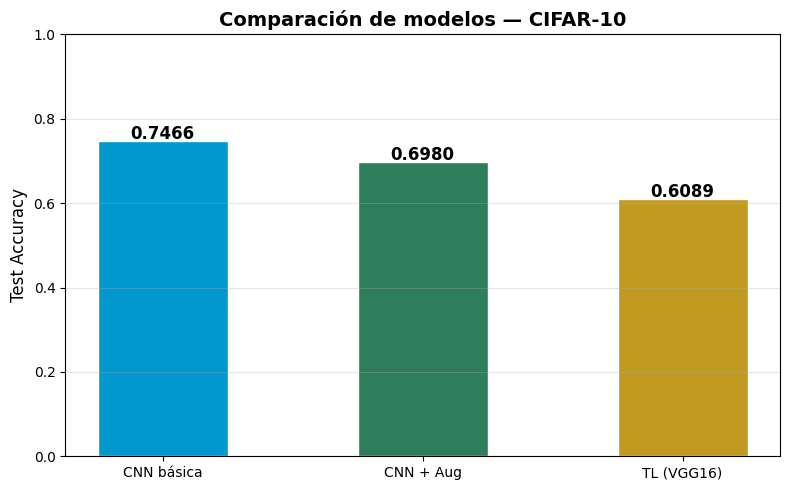

In [17]:
# Tabla comparativa
print("=" * 55)
print(f"{'Modelo':<30} {'Test Accuracy':>12}")
print("=" * 55)
print(f"{'CNN básica (desde cero)':<30} {test_acc:>12.4f}")
print(f"{'CNN + Data Augmentation':<30} {test_acc_aug:>12.4f}")
print(f"{'Transfer Learning (VGG16)':<30} {test_acc_tl:>12.4f}")
print("=" * 55)

# Gráfica comparativa
modelos = ['CNN básica', 'CNN + Aug', 'TL (VGG16)']
accs = [test_acc, test_acc_aug, test_acc_tl]
colores = ['#0098CD', '#2E7D5B', '#C19A1F']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(modelos, accs, color=colores, width=0.5, edgecolor='white')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Comparación de modelos — CIFAR-10', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 🏋️ Ejercicios propuestos

1. **Modifica la arquitectura:** Agrega una cuarta capa convolucional con 256 filtros. ¿Mejora la accuracy?
2. **Experimenta con stride:** Reemplaza un MaxPooling por una convolución con stride 2. ¿Qué pasa?
3. **Fine-tuning:** Descongela las últimas 4 capas de VGG16 y reentrena con learning rate bajo (1e-5). ¿Mejora?
4. **Más augmentation:** Añade `vertical_flip=True` y `brightness_range=[0.8, 1.2]`. ¿Qué efecto tiene?

---

**Nota:** Los resultados exactos pueden variar según la GPU y la semilla aleatoria. Lo importante es la tendencia relativa entre los tres enfoques.